# Independent Test Results

Evaluate the best saved models on the independent test set.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from CartClassifier import CARTClassifier
from RandomForestFromScratch import RandomForestFromScratch

import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

## Load independent test set

In [2]:
test_df = pd.read_csv("../data/processed_sars_cov_2_with_position_specific_features.csv")

DROP_COLS = ["index", "peptide", "HLA", "hla_sequence"]
TARGET_COL = "Label"

y_test = test_df[TARGET_COL].values

X_test = test_df.drop(
    columns=[TARGET_COL] + [c for c in DROP_COLS if c in test_df.columns]
)

cat_cols = X_test.select_dtypes(include=["object", "category"]).columns.tolist()
X_test = pd.get_dummies(X_test, columns=cat_cols)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Classes:", dict(zip(*np.unique(y_test, return_counts=True))))

X_test: (92, 290)
y_test: (92,)
Classes: {np.int64(0): np.int64(57), np.int64(1): np.int64(35)}


In [3]:
BEST_DIR = "../models/best_models"

models = []

for file in os.listdir(BEST_DIR):
    if file.endswith(".pkl"):
        name = file.replace(".pkl", "")

        # skip old decision tree model for now
        if "decision_tree" in name:
            continue

        path = os.path.join(BEST_DIR, file)
        model = joblib.load(path)

        models.append((name, model))

print("Loaded models:")
for name, _ in models:
    print("-", name)

Loaded models:
- adaboost_v4
- xgboost_v4
- random_forest_scratch_v6
- lightgbm_v16


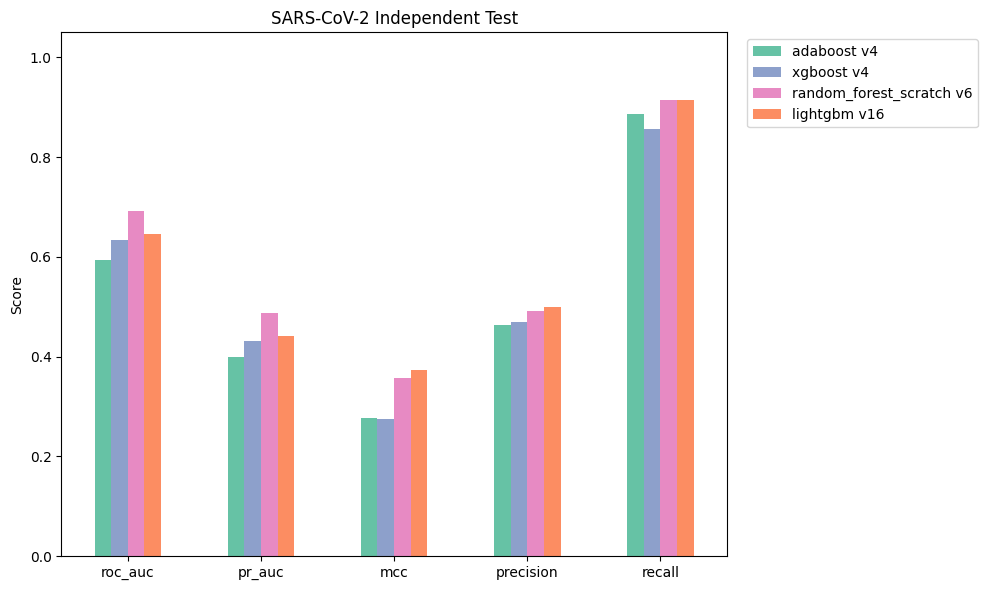

: 

: 

In [ ]:
results = []

for name, model in models:
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    results.append({
        "model": name.replace("_v", " v"),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "mcc": matthews_corrcoef(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(results)

plot_df = results_df.set_index("model")[[
    "roc_auc",
    "pr_auc",
    "mcc",
    "precision",
    "recall"
]]

# define fixed colors per model (same every time)
color_map = {
    "adaboost": "#66c2a5",
    "xgboost": "#8da0cb",
    "lightgbm": "#fc8d62",
    "random_forest": "#e78ac3"
}

# assign colors based on model name
colors = []
for model in plot_df.index:
    if "adaboost" in model:
        colors.append(color_map["adaboost"])
    elif "xgboost" in model:
        colors.append(color_map["xgboost"])
    elif "lightgbm" in model:
        colors.append(color_map["lightgbm"])
    elif "random" in model:
        colors.append(color_map["random_forest"])
    else:
        colors.append("gray")

ax = plot_df.T.plot(kind="bar", figsize=(10,6), color=colors)

plt.title("SARS-CoV-2 Independent Test")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)

plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

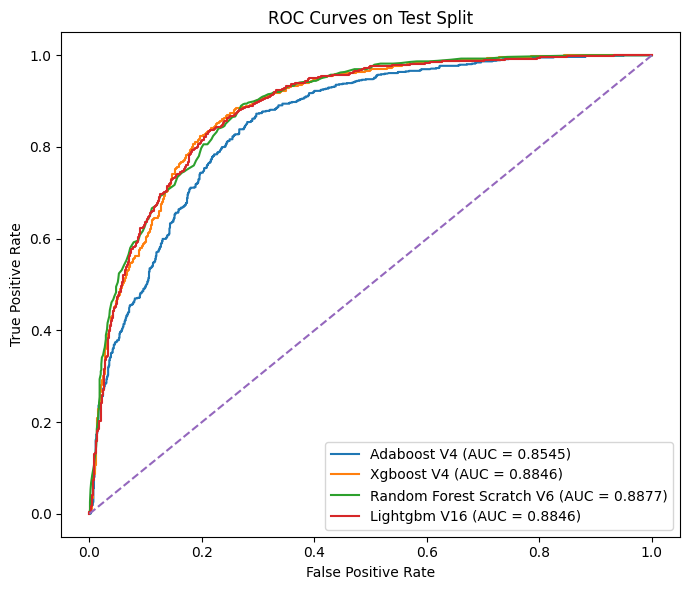

In [4]:

test_df = pd.read_csv("../data/dataset_test.csv")

DROP_COLS = ["index", "peptide", "HLA", "hla_sequence"]
TARGET_COL = "Label"

y_test = test_df[TARGET_COL].values

X_test = test_df.drop(
    columns=[TARGET_COL] + [c for c in DROP_COLS if c in test_df.columns]
)

# same preprocessing as training
cat_cols = X_test.select_dtypes(include=["object", "category"]).columns.tolist()
X_test = pd.get_dummies(X_test, columns=cat_cols)

plt.figure(figsize=(7,6))

for name, model in models:

    if not hasattr(model, "predict_proba"):
        print(f"Skipping {name}")
        continue

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    clean_name = name.replace("_", " ").title()

    plt.plot(fpr, tpr, label=f"{clean_name} (AUC = {roc_auc:.4f})")

# diagonal line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Test Split")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

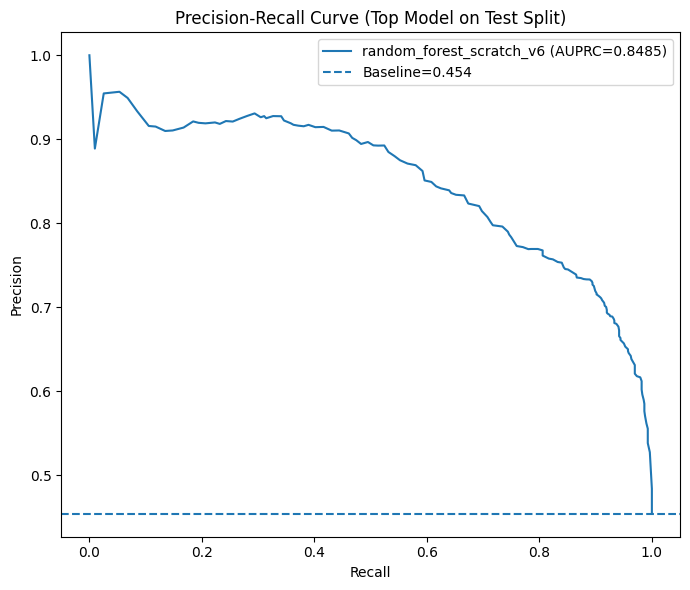

In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,6))

best_pr_auc = -1
best_curve = None
best_name = None

for name, model in models:
    if not hasattr(model, "predict_proba"):
        print(f"Skipping {name}")
        continue

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    if pr_auc > best_pr_auc:
        best_pr_auc = pr_auc
        best_curve = (precision, recall)
        best_name = name

precision, recall = best_curve

plt.plot(recall, precision, label=f"{best_name} (AUPRC={best_pr_auc:.4f})")

# baseline positive rate
baseline = y_test.mean()
plt.axhline(baseline, linestyle="--", label=f"Baseline={baseline:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Top Model on Test Split)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Apply Soft Voting Ensemble

In [9]:
from utils import soft_voting_ensemble

y_ens_pred, y_ens_prob = soft_voting_ensemble(models, X_test)

print("Ensemble Results")
print("ROC-AUC:", roc_auc_score(y_test, y_ens_prob))
print("AUPRC:", average_precision_score(y_test, y_ens_prob))
print("F1:", f1_score(y_test, y_ens_pred))
print("MCC:", matthews_corrcoef(y_test, y_ens_pred))

Ensemble Results
ROC-AUC: 0.890777923642883
AUPRC: 0.843044750220573
F1: 0.7973699940227137
MCC: 0.6244572394997738


In [10]:
# best random forest
rf_model = [m for n, m in models if "random_forest" in n][0]

y_rf_pred = rf_model.predict(X_test)
y_rf_prob = rf_model.predict_proba(X_test)[:, 1]

# ensemble
y_ens_pred, y_ens_prob = soft_voting_ensemble(models, X_test)

print("Random Forest")
print("ROC-AUC:", roc_auc_score(y_test, y_rf_prob))
print("AUPRC:", average_precision_score(y_test, y_rf_prob))
print("F1:", f1_score(y_test, y_rf_pred))
print("MCC:", matthews_corrcoef(y_test, y_rf_pred))

print("\nEnsemble")
print("ROC-AUC:", roc_auc_score(y_test, y_ens_prob))
print("AUPRC:", average_precision_score(y_test, y_ens_prob))
print("F1:", f1_score(y_test, y_ens_pred))
print("MCC:", matthews_corrcoef(y_test, y_ens_pred))

Random Forest
ROC-AUC: 0.887657607790503
AUPRC: 0.8485381490091025
F1: 0.7830188679245284
MCC: 0.5938628278766328

Ensemble
ROC-AUC: 0.890777923642883
AUPRC: 0.843044750220573
F1: 0.7973699940227137
MCC: 0.6244572394997738


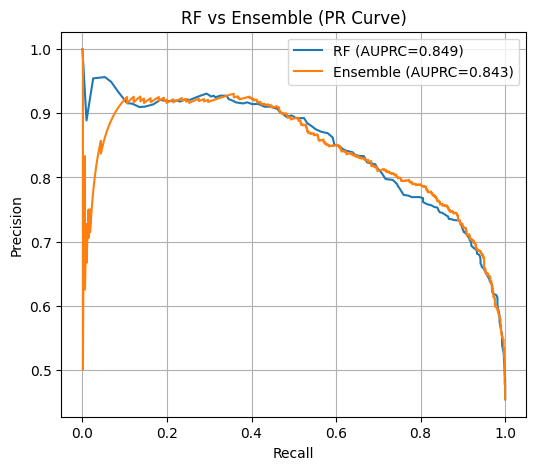

In [11]:
# RF curve
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_rf_prob)
auc_rf = average_precision_score(y_test, y_rf_prob)

# Ensemble curve
prec_ens, rec_ens, _ = precision_recall_curve(y_test, y_ens_prob)
auc_ens = average_precision_score(y_test, y_ens_prob)

plt.figure(figsize=(6,5))

plt.plot(rec_rf, prec_rf, label=f"RF (AUPRC={auc_rf:.3f})")
plt.plot(rec_ens, prec_ens, label=f"Ensemble (AUPRC={auc_ens:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("RF vs Ensemble (PR Curve)")
plt.legend()
plt.grid()
plt.show()


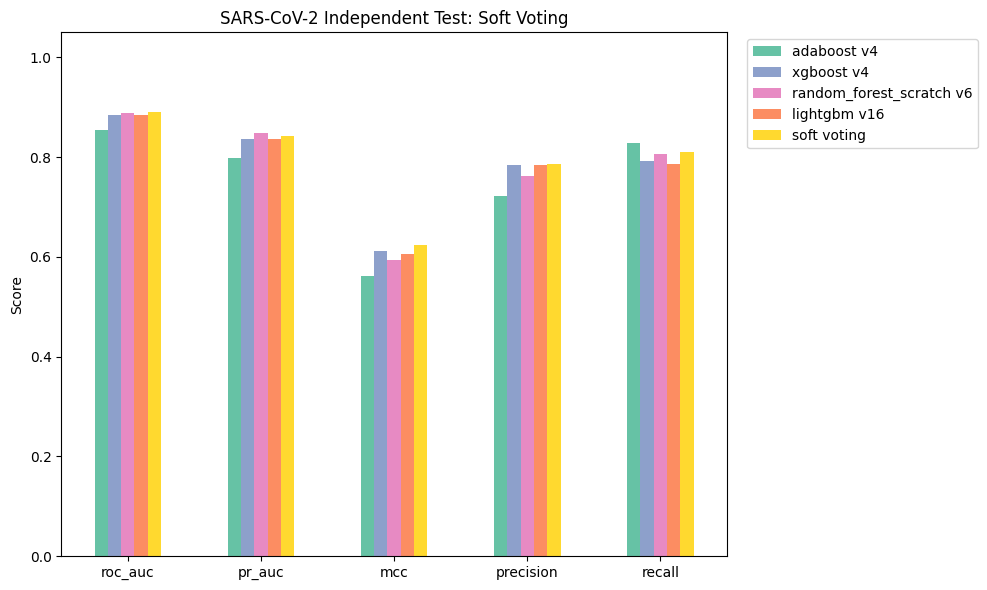

In [13]:


results = []

# individual models
for name, model in models:
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    results.append({
        "model": name.replace("_v", " v"),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "mcc": matthews_corrcoef(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
    })

# unweighted ensemble
y_ens_pred, y_ens_prob = soft_voting_ensemble(models, X_test)

results.append({
    "model": "soft voting",
    "roc_auc": roc_auc_score(y_test, y_ens_prob),
    "pr_auc": average_precision_score(y_test, y_ens_prob),
    "mcc": matthews_corrcoef(y_test, y_ens_pred),
    "precision": precision_score(y_test, y_ens_pred, zero_division=0),
    "recall": recall_score(y_test, y_ens_pred, zero_division=0),
})

results_df = pd.DataFrame(results)

plot_df = results_df.set_index("model")[[
    "roc_auc", "pr_auc", "mcc", "precision", "recall"
]]

color_map = {
    "adaboost": "#66c2a5",
    "xgboost": "#8da0cb",
    "lightgbm": "#fc8d62",
    "random_forest": "#e78ac3",
    "soft voting": "#ffd92f"
}

colors = []
for model in plot_df.index:
    if "adaboost" in model:
        colors.append(color_map["adaboost"])
    elif "xgboost" in model:
        colors.append(color_map["xgboost"])
    elif "lightgbm" in model:
        colors.append(color_map["lightgbm"])
    elif "random" in model:
        colors.append(color_map["random_forest"])
    elif "soft voting" in model:
        colors.append(color_map["soft voting"])
    else:
        colors.append("gray")

ax = plot_df.T.plot(kind="bar", figsize=(10, 6), color=colors)

plt.title("SARS-CoV-2 Independent Test: Soft Voting")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### The soft-voting ensemble did not outperform the best individual model (Random Forest), but improved MCC by 0.2 

## Weighted soft voting ensemble 

In [14]:
from utils import weighted_soft_voting_ensemble

y_weighted_pred, y_weighted_prob = weighted_soft_voting_ensemble(
    models,
    X_test,
    threshold=0.5
)

Used models:
adaboost_v4: 0.05
xgboost_v4: 0.20
random_forest_scratch_v6: 0.60
lightgbm_v16: 0.15


In [15]:
y_w_pred, y_w_prob = weighted_soft_voting_ensemble(
    models,
    X_test,
    threshold=0.5
)

print("Weighted Ensemble Results")
print("ROC-AUC:", roc_auc_score(y_test, y_w_prob))
print("AUPRC:", average_precision_score(y_test, y_w_prob))
print("F1:", f1_score(y_test, y_w_pred))
print("MCC:", matthews_corrcoef(y_test, y_w_pred))

Used models:
adaboost_v4: 0.05
xgboost_v4: 0.20
random_forest_scratch_v6: 0.60
lightgbm_v16: 0.15
Weighted Ensemble Results
ROC-AUC: 0.8915984148599532
AUPRC: 0.8499056881817766
F1: 0.7952662721893491
MCC: 0.6177893531652056


In [16]:
rf_model = [m for n, m in models if "random_forest" in n][0]

y_rf_pred = rf_model.predict(X_test)
y_rf_prob = rf_model.predict_proba(X_test)[:, 1]

# unweighted ensemble
y_ens_pred, y_ens_prob = soft_voting_ensemble(models, X_test)

# weighted ensemble
y_w_pred, y_w_prob = weighted_soft_voting_ensemble(models, X_test)

print("Random Forest")
print("ROC-AUC:", roc_auc_score(y_test, y_rf_prob))
print("AUPRC:", average_precision_score(y_test, y_rf_prob))
print("F1:", f1_score(y_test, y_rf_pred))
print("MCC:", matthews_corrcoef(y_test, y_rf_pred))

print("\nSoft Voting")
print("ROC-AUC:", roc_auc_score(y_test, y_ens_prob))
print("AUPRC:", average_precision_score(y_test, y_ens_prob))
print("F1:", f1_score(y_test, y_ens_pred))
print("MCC:", matthews_corrcoef(y_test, y_ens_pred))

print("\nWeighted Voting")
print("ROC-AUC:", roc_auc_score(y_test, y_w_prob))
print("AUPRC:", average_precision_score(y_test, y_w_prob))
print("F1:", f1_score(y_test, y_w_pred))
print("MCC:", matthews_corrcoef(y_test, y_w_pred))

Used models:
adaboost_v4: 0.05
xgboost_v4: 0.20
random_forest_scratch_v6: 0.60
lightgbm_v16: 0.15
Random Forest
ROC-AUC: 0.887657607790503
AUPRC: 0.8485381490091025
F1: 0.7830188679245284
MCC: 0.5938628278766328

Soft Voting
ROC-AUC: 0.890777923642883
AUPRC: 0.843044750220573
F1: 0.7973699940227137
MCC: 0.6244572394997738

Weighted Voting
ROC-AUC: 0.8915984148599532
AUPRC: 0.8499056881817766
F1: 0.7952662721893491
MCC: 0.6177893531652056
